In [9]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, root_mean_squared_error, r2_score

In [5]:
df = pd.read_csv("Titanic-Dataset.csv")

In [6]:
x = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])

label = LabelEncoder()
x['Embarked'] = label.fit_transform(x['Embarked']) 
x['Sex'] = label.fit_transform(x['Sex'])

impute = SimpleImputer(strategy="median")
x = impute.fit_transform(x)

y = df['Survived']
scale = StandardScaler()
x = scale.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=76, test_size=0.2 )

In [7]:
# base estimator

base_estimator = [
    ('svc', SVC(kernel='rbf')), 
    ('nb', GaussianNB()), 
    ('dt', DecisionTreeClassifier(random_state=42))
]

# usually in base estimator we are using random forest, gradientBoost, XGBoost etc. but we are 
# not using because we have to learn about these models.

In [23]:
# meta model 

meta = LogisticRegression(random_state=42)

In [24]:
stack = StackingClassifier(estimators = base_estimator, 
                           final_estimator = meta, 
                           cv = 5 )#cross validation

In [25]:
model = stack.fit(x_train, y_train)

In [26]:
y_pred = model.predict(x_test)

In [27]:
accuracy_score(y_test, y_pred)

0.8603351955307262

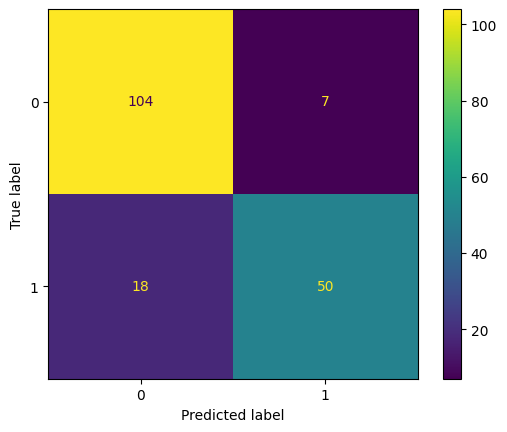

In [28]:
con_mat = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(con_mat).plot()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89       111
           1       0.88      0.74      0.80        68

    accuracy                           0.86       179
   macro avg       0.86      0.84      0.85       179
weighted avg       0.86      0.86      0.86       179



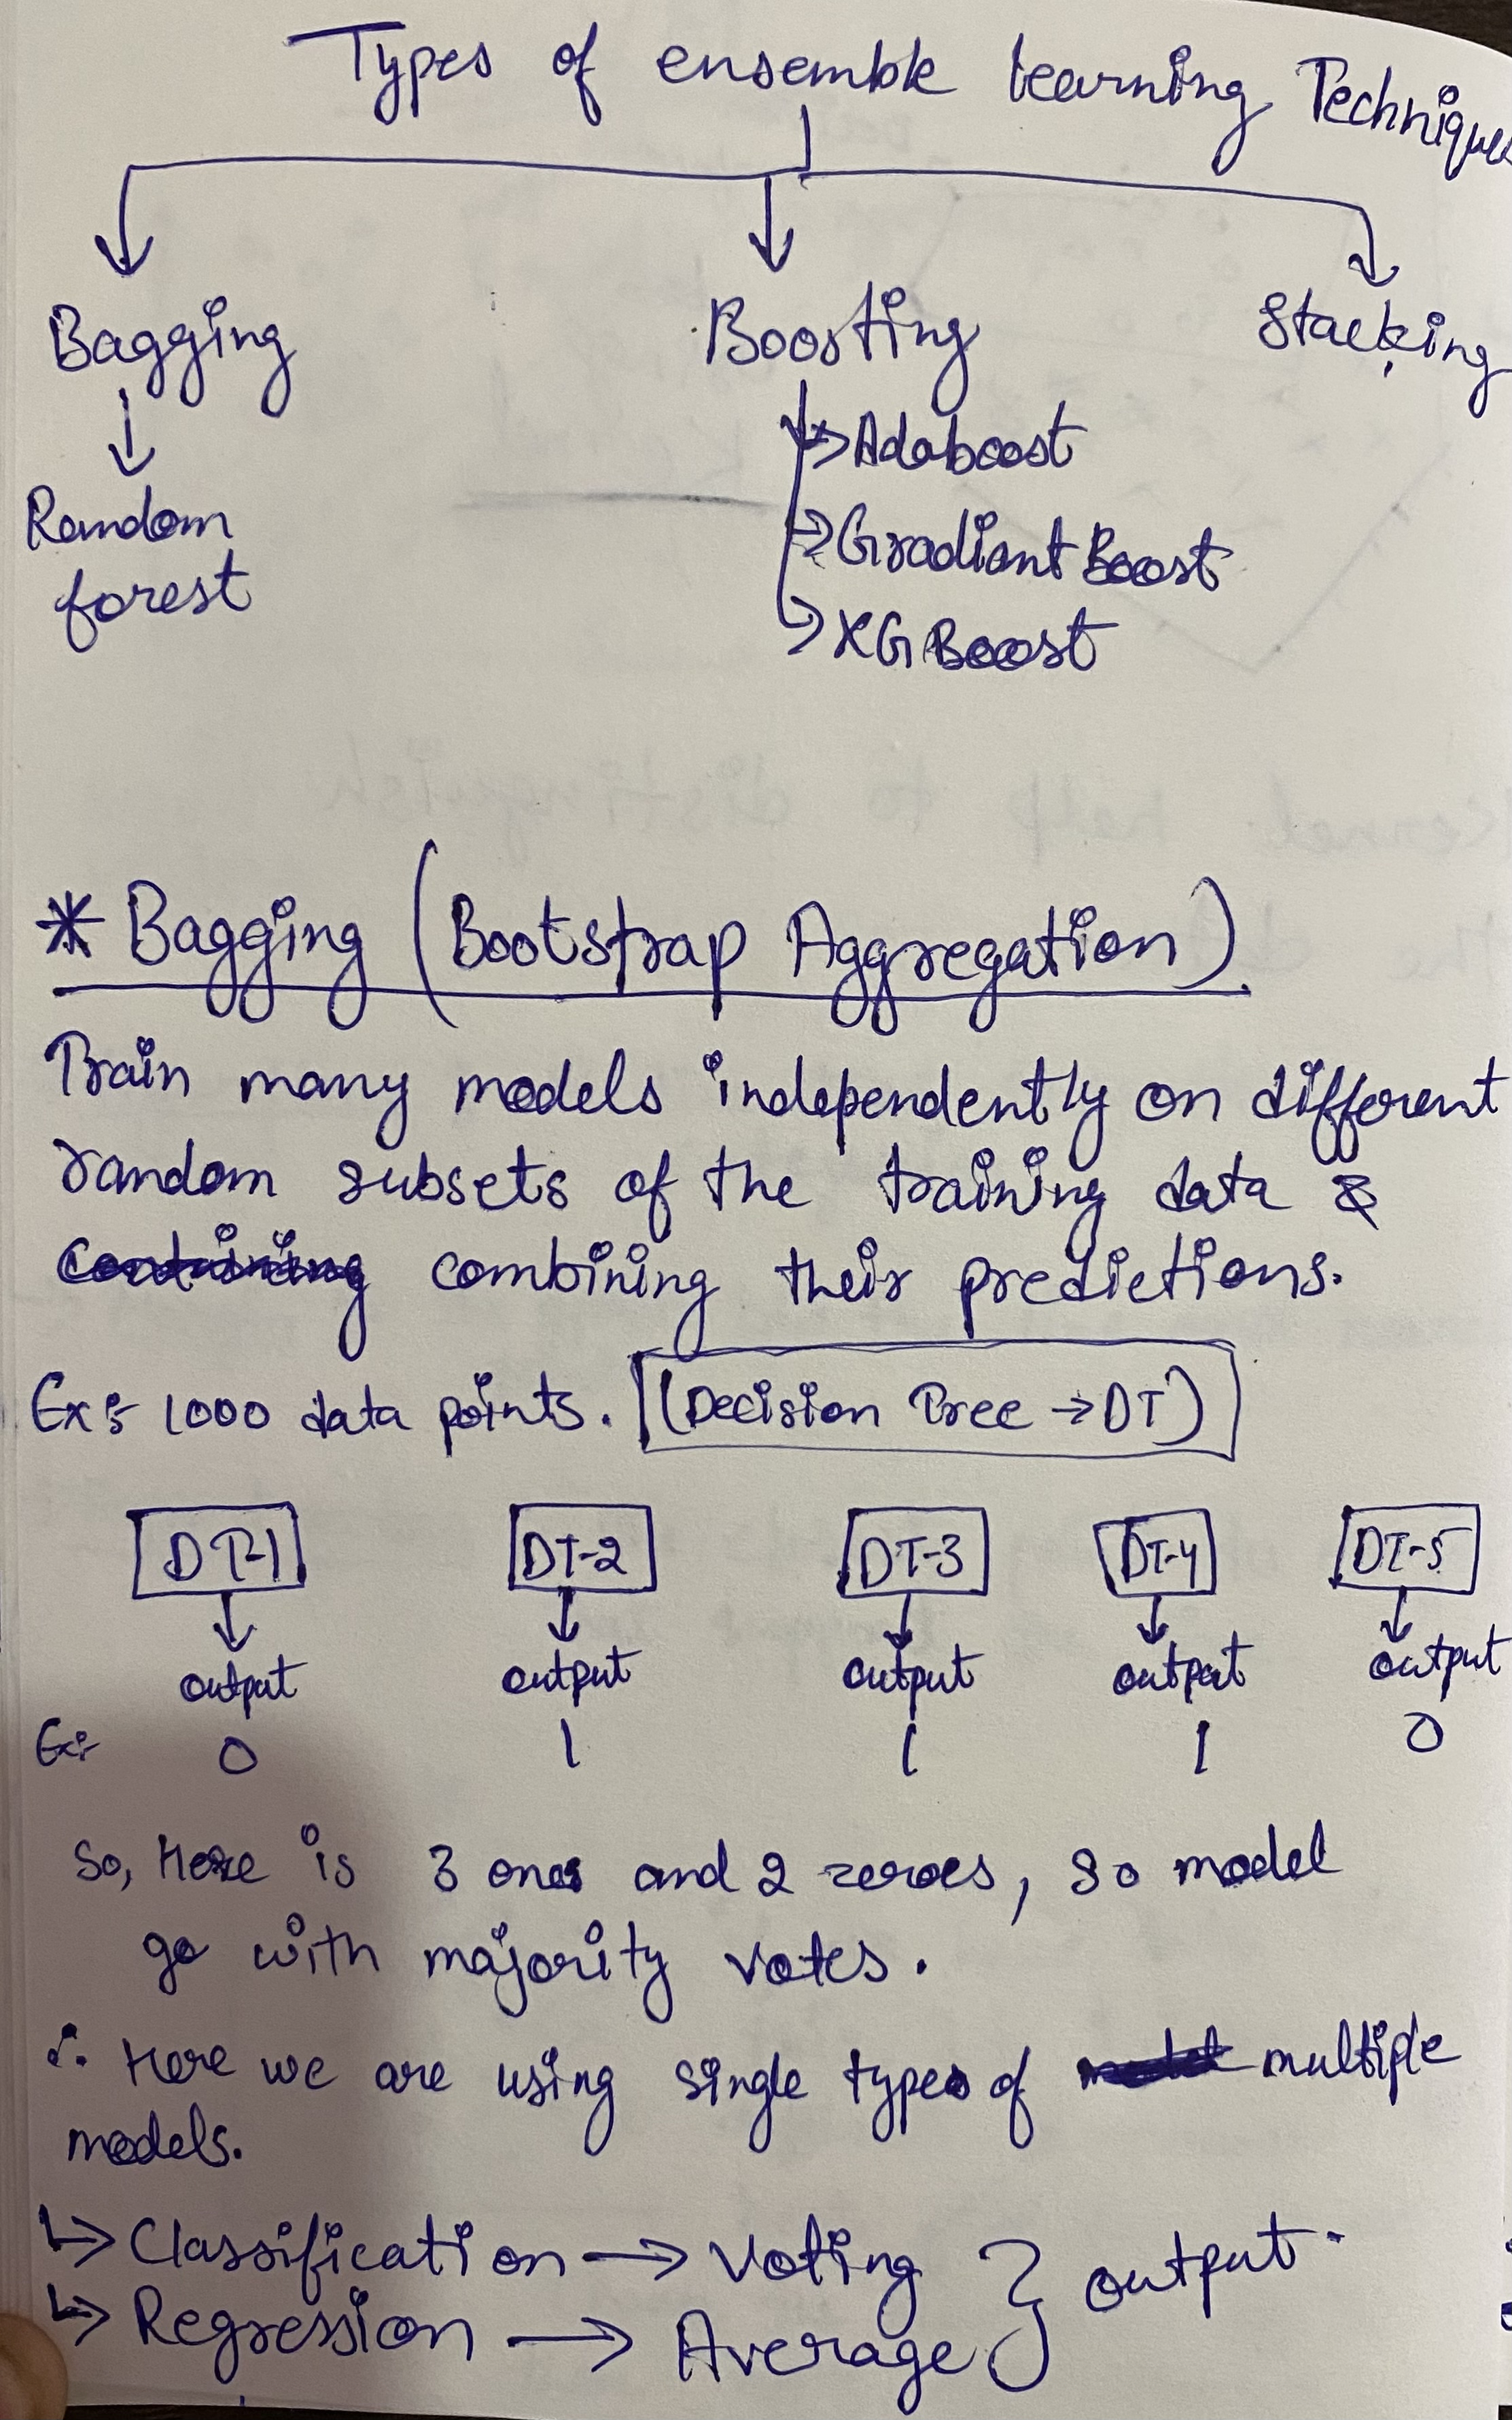
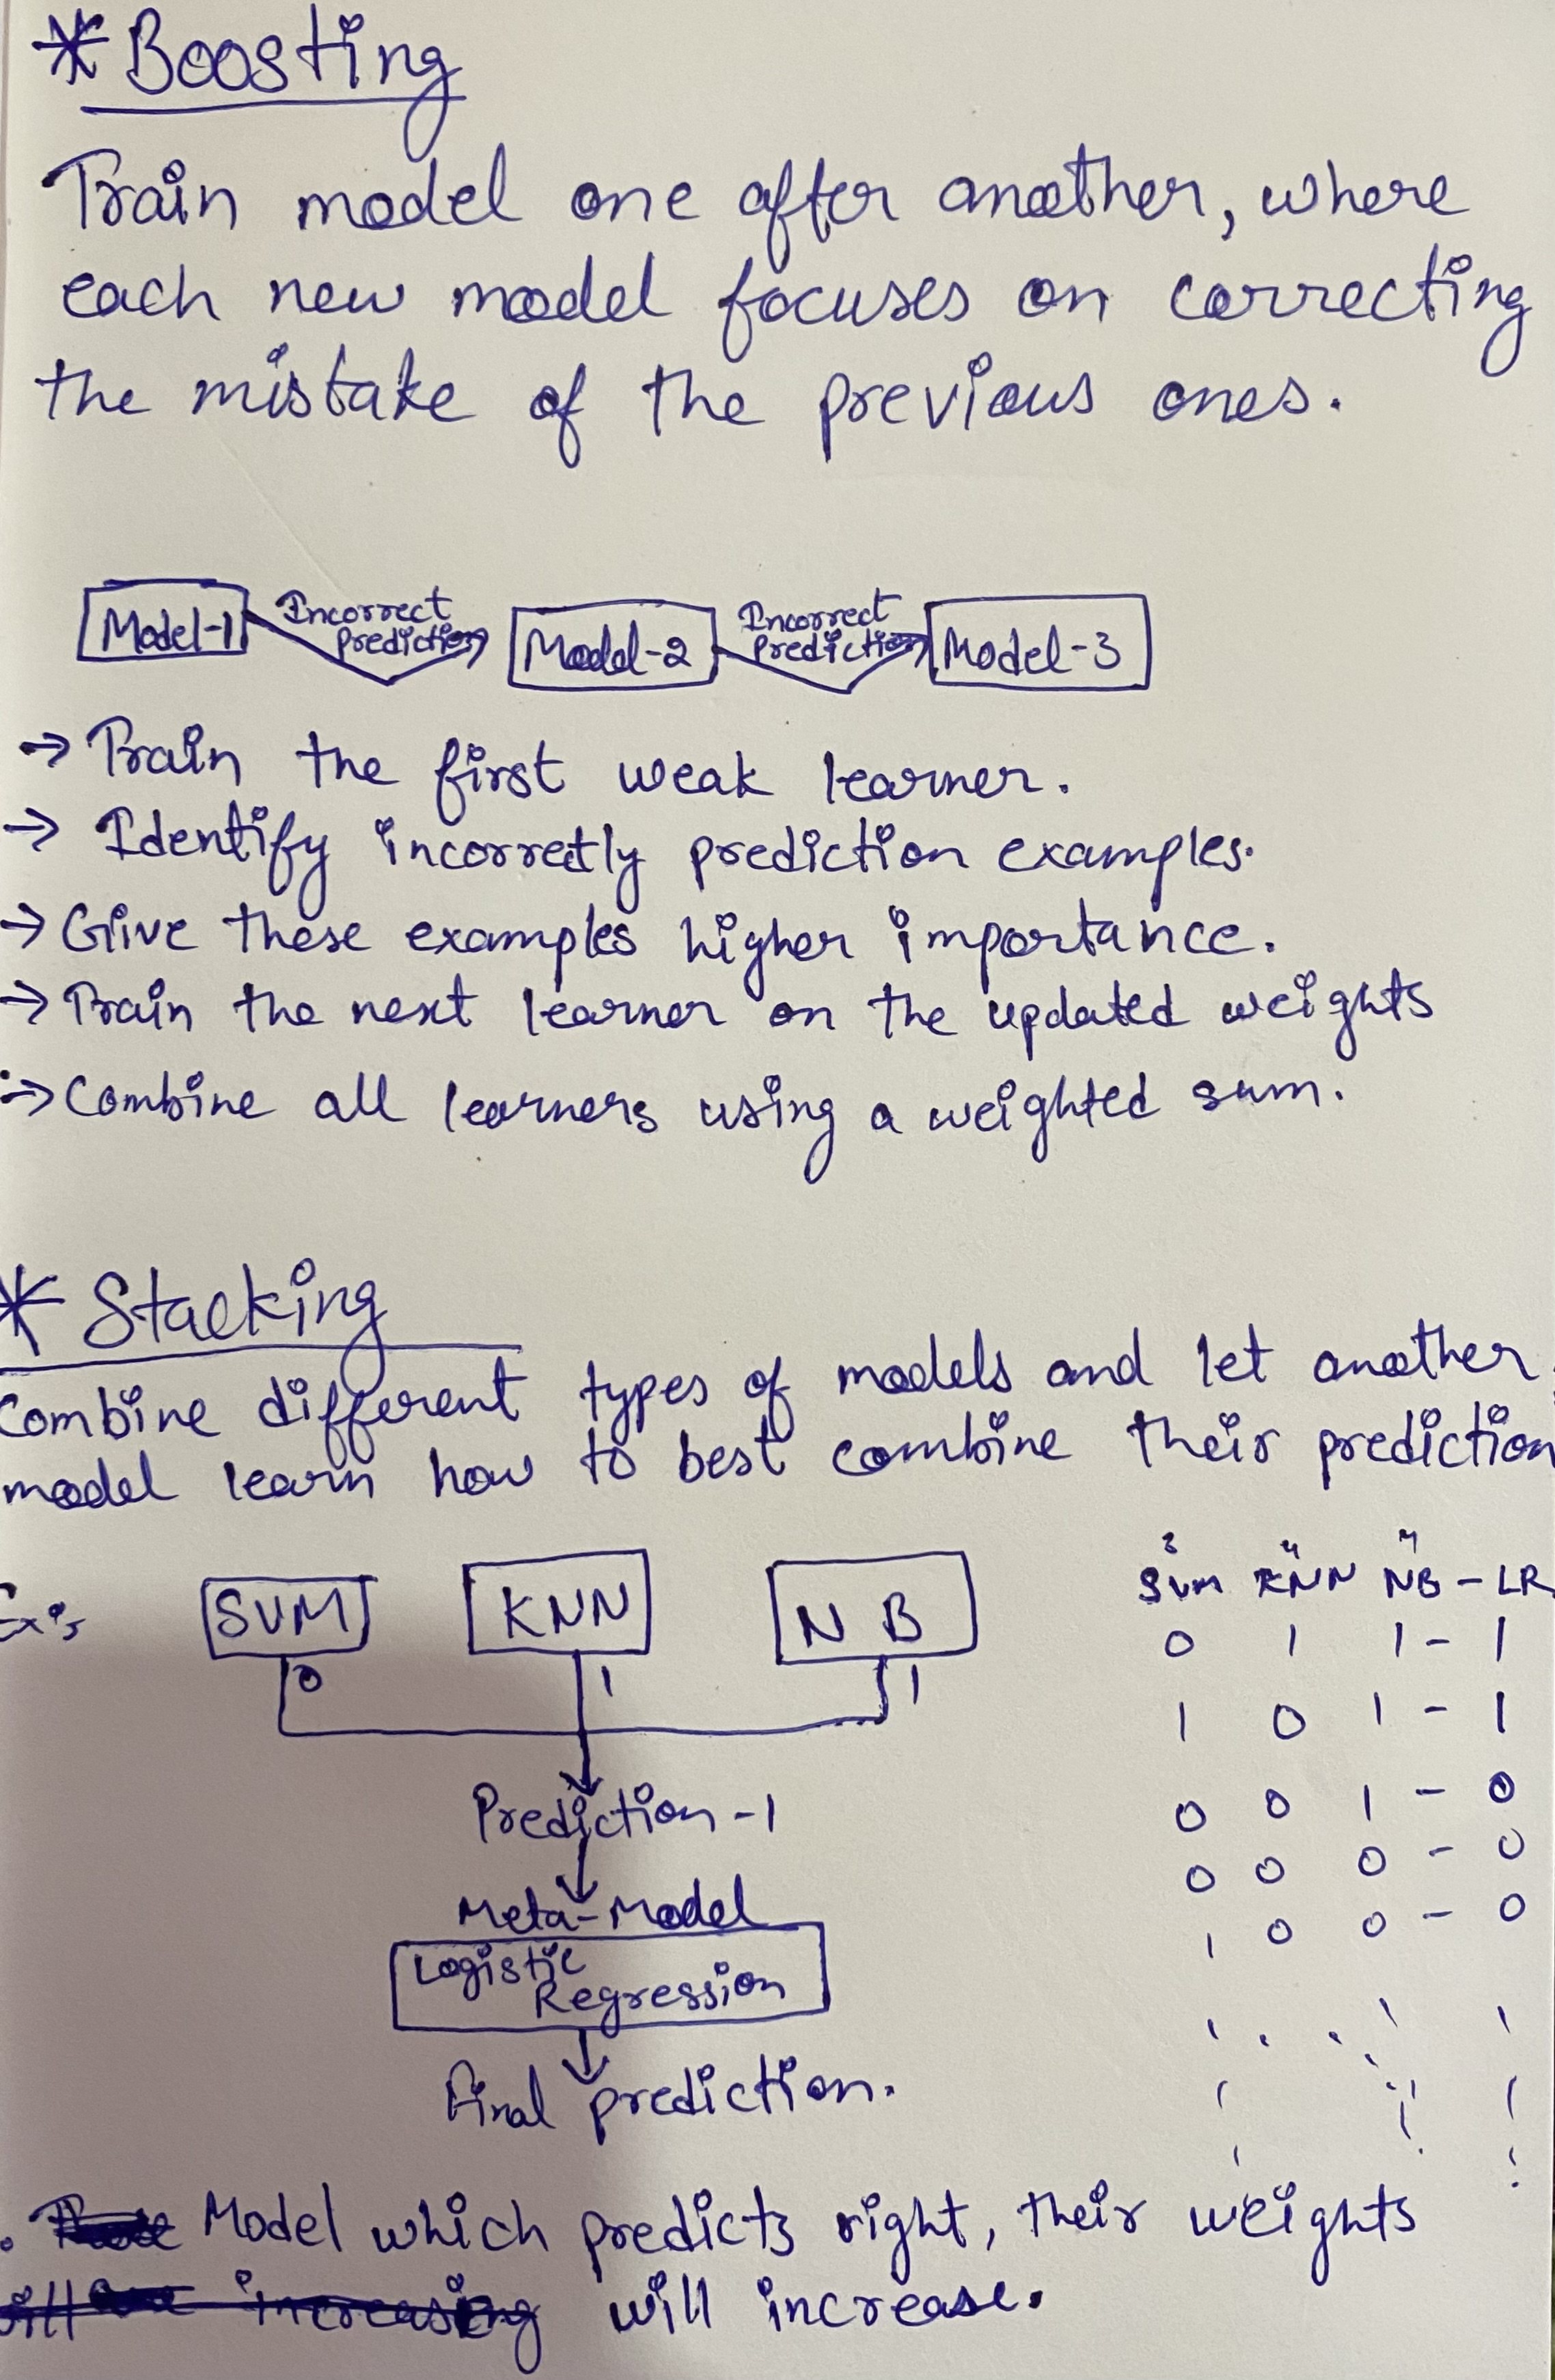